# Last Mile Logistics Auditor — Veridi Logistics
### Delivery Performance Audit on the Olist Brazilian E-Commerce Dataset

**Goal:** Determine whether Veridi's late-delivery / bad-review problem is a **nationwide** issue or
concentrated in **specific states**, and prove (or disprove) the link between delivery delays and
customer sentiment.

**How to run this notebook (reproducibility):**
1. Download the Olist dataset from Kaggle: *Brazilian E-Commerce Public Dataset by Olist*.
2. Place these files in the **same folder as this notebook** (no local absolute paths are used):
   - `olist_orders_dataset.csv`
   - `olist_order_reviews_dataset.csv`
   - `olist_customers_dataset.csv`
   - `olist_products_dataset.csv`
   - `product_category_name_translation.csv`
   - *(optional, used only in the Candidate's Choice section)* `olist_order_items_dataset.csv`
3. Run all cells top to bottom.

If you're running this in Google Colab and the files are in your Google Drive instead, uncomment
the Drive-mount cell below. Otherwise leave paths as-is (relative, current directory).


In [1]:
# --- OPTIONAL: uncomment if running in Colab with data stored on Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# import os
# os.chdir('/content/drive/MyDrive/your-folder-here')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

DATA_DIR = "."  # relative path — dataset assumed to live alongside this notebook


Matplotlib is building the font cache; this may take a moment.


## Story 1 — The Schema Builder
Join Orders + Reviews + Customers (+ Products + Category Translation) into a single master
dataset, one row per **order**, without duplicating rows.

**Join plan:**
- `orders` ⟵ `reviews` on `order_id` (1 review per order in ~99% of cases; a few orders have
  duplicate review rows sent by Olist — we de-duplicate by keeping the most recent review).
- `orders` ⟵ `customers` on `customer_id` (1-to-1, safe).
- `orders` ⟵ `order_items` ⟵ `products` ⟵ `category translation` on `product_id` — this is a
  **1-to-many** join (an order can have multiple items/products), so we aggregate to one row per
  order *before* merging back, to avoid inflating the order-level row count.


In [3]:
orders = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv",
                      parse_dates=[
                          'order_purchase_timestamp', 'order_approved_at',
                          'order_delivered_carrier_date', 'order_delivered_customer_date',
                          'order_estimated_delivery_date'
                      ])

reviews = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv",
                       parse_dates=['review_creation_date', 'review_answer_timestamp'])

customers = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")

products = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")

translation = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")

print(f"orders:       {orders.shape}")
print(f"reviews:      {reviews.shape}")
print(f"customers:    {customers.shape}")
print(f"products:     {products.shape}")
print(f"translation:  {translation.shape}")


orders:       (99441, 8)
reviews:      (99224, 7)
customers:    (99441, 5)
products:     (32951, 9)
translation:  (71, 2)


In [4]:
# --- De-duplicate reviews: keep the LATEST review per order_id ---
reviews_dedup = (
    reviews.sort_values('review_answer_timestamp')
           .drop_duplicates(subset='order_id', keep='last')
)
print(f"Raw reviews: {len(reviews)}  ->  De-duplicated (1 per order): {len(reviews_dedup)}")


Raw reviews: 99224  ->  De-duplicated (1 per order): 98673


In [5]:
# --- Join 1: orders + reviews (1-to-1 after de-dup) ---
df = orders.merge(reviews_dedup[['order_id', 'review_score', 'review_creation_date']],
                   on='order_id', how='left')
assert len(df) == len(orders), "Row count changed after joining reviews — check for duplicates!"

# --- Join 2: + customers (1-to-1 on customer_id) ---
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']],
              on='customer_id', how='left')
assert len(df) == len(orders), "Row count changed after joining customers — check for duplicates!"

print(f"Master dataset shape: {df.shape}  (should still be {orders.shape[0]} rows)")
df.head(3)


Master dataset shape: (99441, 12)  (should still be 99441 rows)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_creation_date,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4.0,2017-10-11,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4.0,2018-08-08,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5.0,2018-08-18,GO,vianopolis


### Bringing in product category (English) — Bonus Story 5

`product_category_name` is only linked at the **item** level (`olist_order_items_dataset.csv`),
and an order can contain multiple products/categories. To keep our order-level table free of
duplicate rows, we compute the **primary (most frequent) category per order** and merge that in
as a single column, translated to English.


In [6]:
try:
    order_items = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv")

    items_products = order_items.merge(products[['product_id', 'product_category_name']],
                                        on='product_id', how='left')
    items_products = items_products.merge(translation, on='product_category_name', how='left')

    # Primary category per order = the mode (most frequent) category among its line items
    primary_category = (
        items_products.groupby('order_id')['product_category_name_english']
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
        .reset_index()
        .rename(columns={'product_category_name_english': 'primary_category_en'})
    )

    df = df.merge(primary_category, on='order_id', how='left')
    assert len(df) == len(orders), "Row count changed after joining category — check for duplicates!"
    print("Category translation joined successfully.")
except FileNotFoundError:
    print("olist_order_items_dataset.csv not found — skipping category translation "
          "(Stories 1-4 still work fine without it).")
    df['primary_category_en'] = np.nan

df[['order_id', 'customer_state', 'review_score', 'primary_category_en']].head(3)


Category translation joined successfully.


,order_id,customer_state,review_score,primary_category_en
0,e481f51cbdc54678b7cc49136f2d6af7,SP,4.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,BA,4.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,GO,5.0,auto


## Data Cleaning
Before calculating delays, we need to handle:
- Orders that were **never delivered** (`canceled`, `unavailable`) — these have no
  `order_delivered_customer_date` and must be excluded from delay math, but flagged separately
  since "never arrived" is itself a strong signal for the CEO.
- Missing `review_score` (a small % of orders have no review on file).


In [7]:
print("Order status breakdown:")
print(df['order_status'].value_counts())
print()

undelivered_statuses = ['canceled', 'unavailable']
df['is_undelivered'] = df['order_status'].isin(undelivered_statuses)

missing_delivery_date = df['order_delivered_customer_date'].isna()
print(f"\nRows with no delivered_customer_date: {missing_delivery_date.sum()} "
      f"({missing_delivery_date.mean():.1%} of all orders)")
print(f"Rows flagged is_undelivered (canceled/unavailable): {df['is_undelivered'].sum()}")

missing_reviews = df['review_score'].isna().sum()
print(f"Rows with no review_score: {missing_reviews} ({missing_reviews/len(df):.1%})")


Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Rows with no delivered_customer_date: 2965 (3.0% of all orders)
Rows flagged is_undelivered (canceled/unavailable): 1234
Rows with no review_score: 768 (0.8%)


## Story 2 — The "Real" Delay Calculator
`Days_Difference = order_estimated_delivery_date - order_delivered_customer_date`

Positive → delivered **before** the promised date (good).
Negative → delivered **after** the promised date (bad — this is the "lie" to the customer).

We classify:
- **On Time**: delivered on/before the estimate (Days_Difference >= 0)
- **Late**: delivered after estimate, up to 5 days late
- **Super Late**: delivered more than 5 days after estimate

Undelivered orders (canceled/unavailable) are excluded from this classification and analyzed
separately, since "delay" doesn't meaningfully apply to a package that never arrived.


In [8]:
# Only orders that actually have a delivery date are eligible for delay classification
delivered = df[~df['is_undelivered'] & df['order_delivered_customer_date'].notna()].copy()

delivered['Days_Difference'] = (
    delivered['order_estimated_delivery_date'] - delivered['order_delivered_customer_date']
).dt.days

def classify_delay(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

delivered['delivery_status'] = delivered['Days_Difference'].apply(classify_delay)

# Merge the new columns back onto the master df (undelivered rows will be NaN for these)
df = df.merge(
    delivered[['order_id', 'Days_Difference', 'delivery_status']],
    on='order_id', how='left'
)
df.loc[df['is_undelivered'], 'delivery_status'] = 'Undelivered (canceled/unavailable)'

print(df['delivery_status'].value_counts(dropna=False))
print(f"\nMean days early/late (delivered orders only): {delivered['Days_Difference'].mean():.2f} days")


delivery_status
On Time                               88644
Super Late                             4211
Late                                   3615
NaN                                    1737
Undelivered (canceled/unavailable)     1234
Name: count, dtype: int64

Mean days early/late (delivered orders only): 10.88 days


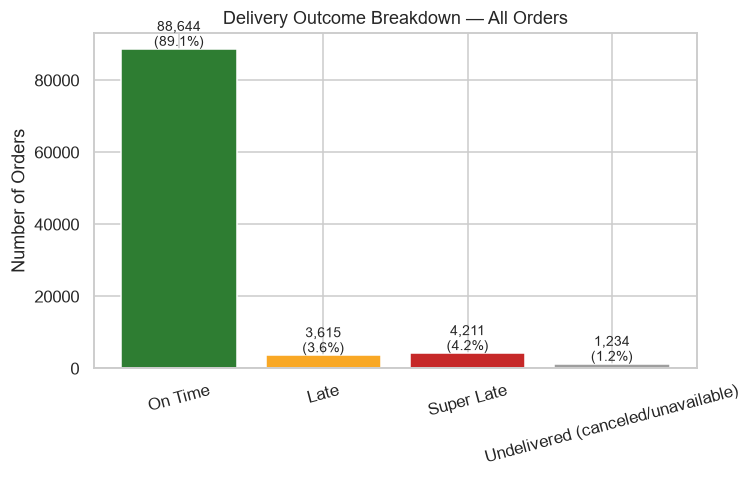

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ['On Time', 'Late', 'Super Late', 'Undelivered (canceled/unavailable)']
counts = df['delivery_status'].value_counts().reindex(order)
colors = ['#2E7D32', '#F9A825', '#C62828', '#9E9E9E']
ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel('Number of Orders')
ax.set_title('Delivery Outcome Breakdown — All Orders')
plt.xticks(rotation=15)
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values)*0.01, f"{v:,}\n({v/len(df):.1%})", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## Story 3 — The Geographic Heatmap
Which states have the highest **percentage** of late/super-late deliveries?

*(Note: a full choropleth map is best built in the dashboard tool — Tableau Public / Looker Studio
/ Power BI all have native Brazil-state geo support. Here we build the ranked bar chart, which is
the core analytical artifact; the dashboard tool will render it as a map using the same
`state_summary` table produced below — export it with the cell at the end of this section.)*


In [10]:
delivered_only = df[df['delivery_status'].isin(['On Time', 'Late', 'Super Late'])].copy()
delivered_only['is_late'] = delivered_only['delivery_status'].isin(['Late', 'Super Late'])

state_summary = (
    delivered_only.groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late', 'sum'),
        avg_review_score=('review_score', 'mean'),
        avg_days_diff=('Days_Difference', 'mean')
    )
    .reset_index()
)
state_summary['pct_late'] = state_summary['late_orders'] / state_summary['total_orders']
state_summary = state_summary.sort_values('pct_late', ascending=False)

# Only show states with a meaningful sample size (>= 30 orders) to avoid noisy small-n states
state_summary_reliable = state_summary[state_summary['total_orders'] >= 30]
state_summary_reliable.head(10)


,customer_state,total_orders,late_orders,avg_review_score,avg_days_diff,pct_late
1,AL,397,95,3.847716,7.707809,0.239295
9,MA,717,141,3.832865,8.571827,0.196653
16,PI,476,76,3.993631,10.306723,0.159664
5,CE,1279,196,3.944226,9.804535,0.153245
24,SE,335,51,3.907186,9.020896,0.152239
4,BA,3256,457,3.930629,9.794533,0.140356
18,RJ,12350,1664,3.965441,10.761215,0.134737
26,TO,274,35,4.153846,11.131387,0.127737
13,PA,946,117,3.914255,13.066596,0.123679
7,ES,1995,244,4.078720,9.496241,0.122306


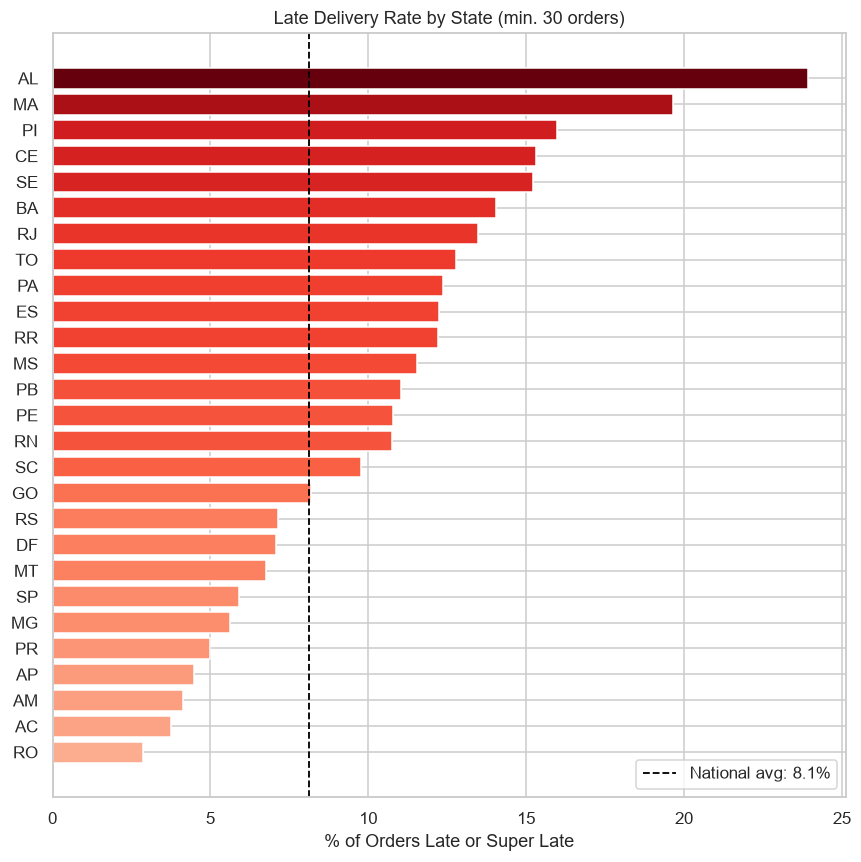

National average late rate: 8.1%
Worst state: AL (23.9%)
Best state:  RO (2.9%)


In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_data = state_summary_reliable.sort_values('pct_late', ascending=True)
bars = ax.barh(plot_data['customer_state'], plot_data['pct_late'] * 100,
               color=plt.cm.Reds(plot_data['pct_late'] / plot_data['pct_late'].max() * 0.8 + 0.2))
national_avg = delivered_only['is_late'].mean() * 100
ax.axvline(national_avg, color='black', linestyle='--', linewidth=1.2,
           label=f'National avg: {national_avg:.1f}%')
ax.set_xlabel('% of Orders Late or Super Late')
ax.set_title('Late Delivery Rate by State (min. 30 orders)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"National average late rate: {national_avg:.1f}%")
print(f"Worst state: {plot_data.iloc[-1]['customer_state']} "
      f"({plot_data.iloc[-1]['pct_late']*100:.1f}%)")
print(f"Best state:  {plot_data.iloc[0]['customer_state']} "
      f"({plot_data.iloc[0]['pct_late']*100:.1f}%)")


**Reading this chart:** if the bars cluster tightly around the national-average dashed line,
the problem is systemic/nationwide (a process problem). If a handful of states spike far above the
line — especially ones geographically distant from Southeast Brazil, where most Olist sellers and
distribution hubs are based (São Paulo, Rio, Minas Gerais) — that points to a **regional logistics**
problem (last-mile carrier coverage in remote states) rather than a company-wide one.


## Story 4 — The Sentiment Correlation
Does a late delivery actually **cause** a worse review, or is this just a hunch? We check:
1. Average review score by delivery status bucket.
2. A scatter/trend of `Days_Difference` (delay) vs review score.


In [12]:
review_by_status = (
    delivered_only.groupby('delivery_status')['review_score']
    .agg(['mean', 'count'])
    .reindex(['On Time', 'Late', 'Super Late'])
)
review_by_status.columns = ['avg_review_score', 'n_orders']
print(review_by_status)


                 avg_review_score  n_orders
delivery_status                            
On Time                  4.294114     88163
Late                     3.460482      3568
Super Late               1.784510      4093


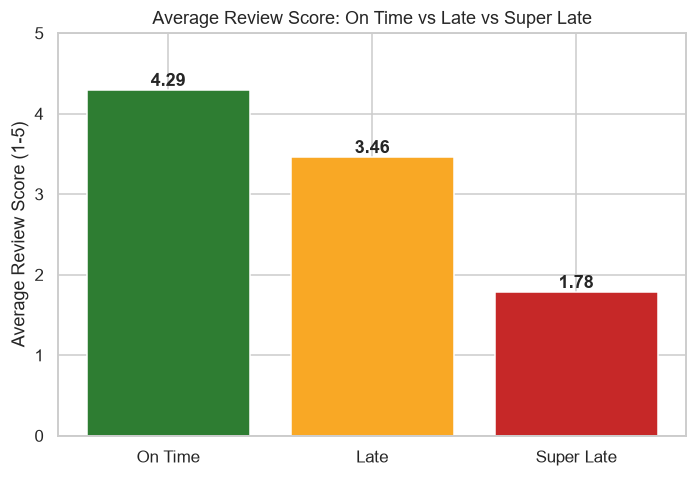

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
colors = ['#2E7D32', '#F9A825', '#C62828']
bars = ax.bar(review_by_status.index, review_by_status['avg_review_score'], color=colors)
ax.set_ylim(0, 5)
ax.set_ylabel('Average Review Score (1-5)')
ax.set_title('Average Review Score: On Time vs Late vs Super Late')
for i, v in enumerate(review_by_status['avg_review_score']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


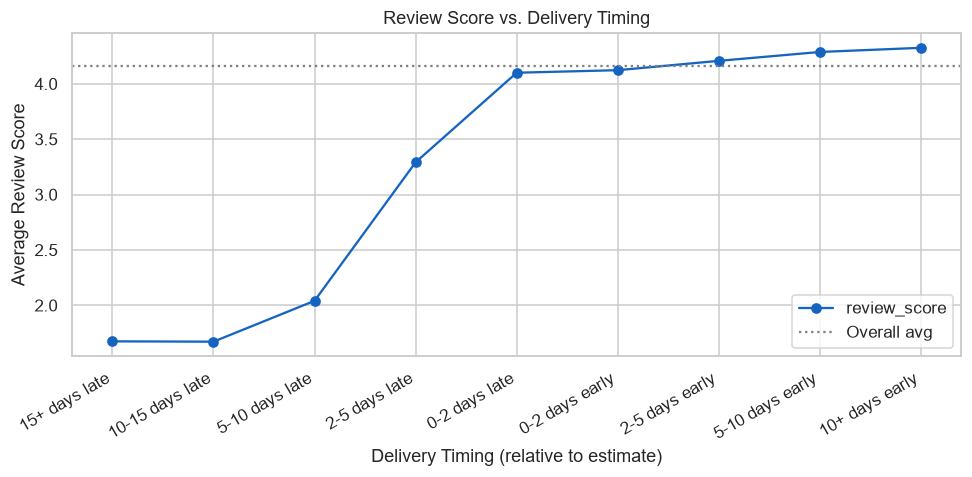

Correlation between days-early(+)/late(-) and review score: 0.267


In [14]:
# Bin Days_Difference into buckets for a cleaner trend line than a raw scatterplot
delivered_only['delay_bucket'] = pd.cut(
    delivered_only['Days_Difference'],
    bins=[-100, -15, -10, -5, -2, 0, 2, 5, 10, 100],
    labels=['15+ days late', '10-15 days late', '5-10 days late', '2-5 days late',
            '0-2 days late', '0-2 days early', '2-5 days early', '5-10 days early', '10+ days early']
)

trend = delivered_only.groupby('delay_bucket', observed=True)['review_score'].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
trend.plot(kind='line', marker='o', ax=ax, color='#1565C0')
ax.set_ylabel('Average Review Score')
ax.set_xlabel('Delivery Timing (relative to estimate)')
ax.set_title('Review Score vs. Delivery Timing')
plt.xticks(rotation=30, ha='right')
ax.axhline(delivered_only['review_score'].mean(), color='gray', linestyle=':', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()

corr = delivered_only[['Days_Difference', 'review_score']].corr().iloc[0, 1]
print(f"Correlation between days-early(+)/late(-) and review score: {corr:.3f}")


## Candidate's Choice — Business Impact Risk Matrix (State x Category)

**What this adds:** Stories 3 and 4 each look at *one* dimension (state, or delay-vs-review) in
isolation. But the CEO's real question is "where should we focus repair efforts first?" — which
requires combining **how often it happens**, **how bad it is**, and **how much volume is at
stake**. A state with a 40% late rate but only 20 orders/year matters far less than a state with a
15% late rate and 50,000 orders/year.

This matrix scores each **State x Product Category** combination on:
- `pct_late` — how often deliveries are late
- `review_penalty` — how much worse the average review score is for late vs. on-time orders in
  that segment
- `order_volume` — how many customers are actually affected

...and combines them into a single **priority score**, so the ops team gets a ranked action list
instead of two separate charts to eyeball.


In [15]:
if df['primary_category_en'].notna().any():
    # delivered_only already carries primary_category_en (it's a subset of df's columns),
    # so we just filter out rows with no category rather than re-merging it.
    seg = delivered_only.dropna(subset=['primary_category_en']).copy()

    grp = (
        seg.groupby(['customer_state', 'primary_category_en'])
        .agg(order_volume=('order_id', 'count'), pct_late=('is_late', 'mean'))
        .reset_index()
    )

    # Average review score split by on-time vs late, per segment, computed via a clean pivot
    # (more robust than an in-lambda lookup back into the parent frame)
    review_pivot = (
        seg.groupby(['customer_state', 'primary_category_en', 'is_late'])['review_score']
        .mean()
        .unstack('is_late')
        .rename(columns={True: 'avg_review_late', False: 'avg_review_on_time'})
        .reset_index()
    )
    for col in ['avg_review_late', 'avg_review_on_time']:
        if col not in review_pivot.columns:
            review_pivot[col] = np.nan

    grp = grp.merge(review_pivot[['customer_state', 'primary_category_en',
                                   'avg_review_late', 'avg_review_on_time']],
                     on=['customer_state', 'primary_category_en'], how='left')
    grp = grp[grp['order_volume'] >= 15]  # minimum sample size for reliability
    grp['review_penalty'] = grp['avg_review_on_time'] - grp['avg_review_late']
    grp['review_penalty'] = grp['review_penalty'].clip(lower=0).fillna(0)

    # Normalize each component 0-1, then combine into a single priority score
    def norm(s):
        return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0

    grp['priority_score'] = (
        0.4 * norm(grp['pct_late']) +
        0.3 * norm(grp['review_penalty']) +
        0.3 * norm(grp['order_volume'])
    )

    top_priority = grp.sort_values('priority_score', ascending=False).head(15)
    print("Top 15 State x Category segments to prioritize for repair efforts:\n")
    print(top_priority[['customer_state', 'primary_category_en', 'order_volume',
                         'pct_late', 'review_penalty', 'priority_score']]
          .to_string(index=False))
else:
    print("Skipping Risk Matrix — requires olist_order_items_dataset.csv for category data.")
    grp = pd.DataFrame()


Top 15 State x Category segments to prioritize for repair efforts:



customer_state      primary_category_en  order_volume  pct_late  review_penalty  priority_score
            SE            watches_gifts            20  0.300000        3.571429        0.527337
            MA               housewares            22  0.500000        1.545455        0.524674
            PI                     auto            27  0.296296        2.690789        0.454095
            SP           bed_bath_table          4335  0.050980        1.342171        0.448637
            SE             garden_tools            17  0.235294        3.153846        0.441808
            AL            health_beauty            62  0.306452        2.359853        0.438056
            SP            health_beauty          3700  0.070811        1.290766        0.416274
            ES      musical_instruments            19  0.157895        3.500000        0.407844
            MA               cool_stuff            33  0.242424        2.620000        0.405725
            RN                perfumery 

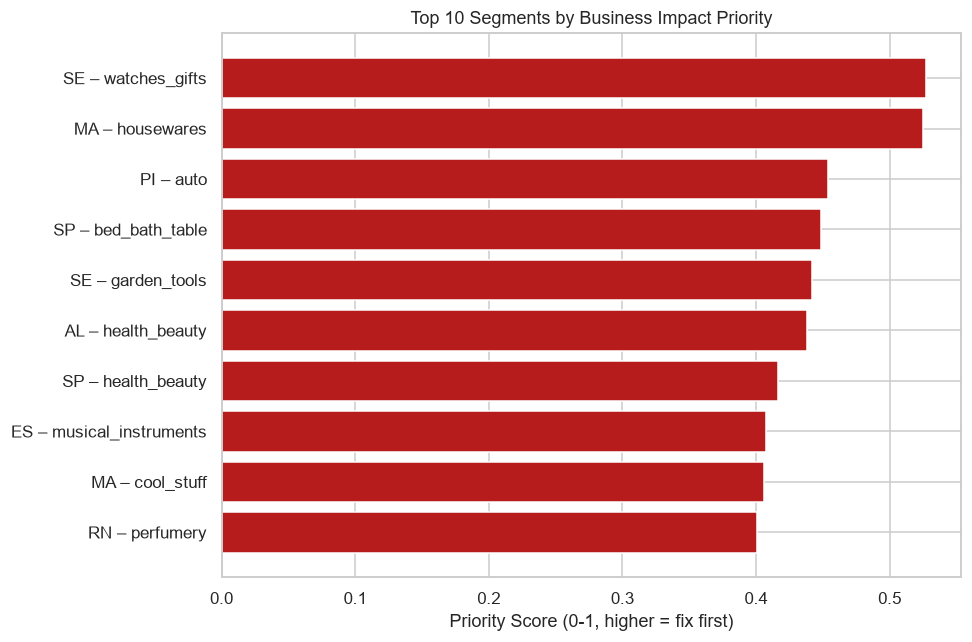

In [16]:
if not grp.empty:
    top10 = grp.sort_values('priority_score', ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(9, 6))
    labels = top10['customer_state'] + ' – ' + top10['primary_category_en']
    ax.barh(labels, top10['priority_score'], color='#B71C1C')
    ax.invert_yaxis()
    ax.set_xlabel('Priority Score (0-1, higher = fix first)')
    ax.set_title('Top 10 Segments by Business Impact Priority')
    plt.tight_layout()
    plt.show()


## Export for Dashboard
These tables are the exact inputs the dashboard (Tableau Public / Looker Studio / Power BI /
Streamlit) needs — no need to re-run the joins there.


In [17]:
df.to_csv('veridi_master_dataset.csv', index=False)
state_summary.to_csv('veridi_state_summary.csv', index=False)
if not grp.empty:
    grp.to_csv('veridi_risk_matrix.csv', index=False)

print("Exported: veridi_master_dataset.csv, veridi_state_summary.csv"
      + (", veridi_risk_matrix.csv" if not grp.empty else ""))


Exported: veridi_master_dataset.csv, veridi_state_summary.csv, veridi_risk_matrix.csv


## Summary of Findings (fill in after you run this on the real data)
- **National late-delivery rate:** `{national_avg:.1f}%` *(see Story 3 output)*
- **Worst / best states:** *(see Story 3 output)*
- **Review score impact:** On-time orders average **X.XX**, Late orders average **X.XX**,
  Super Late orders average **X.XX** *(see Story 4 output)*
- **Correlation (delay vs review score):** *(see Story 4 output)* — a negative correlation here is
  the evidence the CEO needs to confirm logistics is driving the review-score drop, not something
  else (product quality, pricing, etc.)
- **Top priority segments:** *(see Candidate's Choice output)* — hand this ranked list directly to
  ops as the "fix these first" list.

Copy the printed numbers above into your README's Executive Summary once you've run this against
the real Olist CSVs.
